<a href="https://colab.research.google.com/github/NiroNithy/Personal_Portfolio/blob/Research/People's_Features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [ ]:
#LOAD THE DATA
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

df=pd.read_csv('/content/PeopleBank Dataset.csv',encoding='ISO-8859-1')
df

,content,at,appVersion
0,"After the recent update, I can't use the app. ...",2025-01-25T06:58:49,V 1.36.1.2
1,"Shows me a message after the latest update. ""T...",2025-01-25T06:12:57,V 1.36.1.2
2,Not opening without finger print. My phone is ...,2025-01-25T03:05:31,V 1.36.1.2
3,I updated this app on 25 th January 2025. Afte...,2025-01-25T01:09:05,V 1.36.1.2
4,Every time Unable connect server what's this ð...,2025-01-23T12:39:13,V 1.34.1.2
...,...,...,...
915,Super,2022-01-18T06:42:34,V 1.24.1.2
916,Register step 3 problem,2022-01-17T09:37:47,V 1.24.1.2
917,Too much authentication,2022-01-14T23:48:56,V 1.24.1.2
918,"Transaction confirmation pdf not received. So,...",2022-01-11T07:04:08,V 1.24.1.2


In [ ]:
# Download NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
# Preprocessing function
def preprocess_text(text):
    stop_words = set(stopwords.words('english'))
    words = word_tokenize(text.lower())  # Tokenize and convert to lowercase
    return ' '.join(word for word in words if word.isalnum() and word not in stop_words)

In [ ]:
# Apply preprocessing to the content column
df['cleaned_content'] = df['content'].apply(preprocess_text)

In [ ]:
df

,content,at,appVersion,cleaned_content
0,"After the recent update, I can't use the app. ...",2025-01-25T06:58:49,V 1.36.1.2,recent update ca use app keep showing device a...
1,"Shows me a message after the latest update. ""T...",2025-01-25T06:12:57,V 1.36.1.2,shows message latest update device app signatu...
2,Not opening without finger print. My phone is ...,2025-01-25T03:05:31,V 1.36.1.2,opening without finger print phone available f...
3,I updated this app on 25 th January 2025. Afte...,2025-01-25T01:09:05,V 1.36.1.2,updated app 25 th january open app message app...
4,Every time Unable connect server what's this ð...,2025-01-23T12:39:13,V 1.34.1.2,every time unable connect server
...,...,...,...,...
915,Super,2022-01-18T06:42:34,V 1.24.1.2,super
916,Register step 3 problem,2022-01-17T09:37:47,V 1.24.1.2,register step 3 problem
917,Too much authentication,2022-01-14T23:48:56,V 1.24.1.2,much authentication
918,"Transaction confirmation pdf not received. So,...",2022-01-11T07:04:08,V 1.24.1.2,transaction confirmation pdf received prove so...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
#Initialize VADER Sentiment Analyzer
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [ ]:
sia = SentimentIntensityAnalyzer()

In [ ]:
#Take Sentiment Score
def classify_sentiment(score):
  if score >= 0.05:
    return 'positive'
  elif score <= 0.05:
    return 'negative'
  else:
    return 'netural'

#new output column as sentiment score(value)
df['sentiment_score'] = df['content'].apply(lambda x:sia.polarity_scores(x)['compound'])
df['sentiment'] = df['sentiment_score'].apply(classify_sentiment)

In [ ]:
df

,content,at,appVersion,cleaned_content,sentiment_score,sentiment
0,"After the recent update, I can't use the app. ...",2025-01-25T06:58:49,V 1.36.1.2,recent update ca use app keep showing device a...,0.3182,positive
1,"Shows me a message after the latest update. ""T...",2025-01-25T06:12:57,V 1.36.1.2,shows message latest update device app signatu...,0.0000,negative
2,Not opening without finger print. My phone is ...,2025-01-25T03:05:31,V 1.36.1.2,opening without finger print phone available f...,0.0000,negative
3,I updated this app on 25 th January 2025. Afte...,2025-01-25T01:09:05,V 1.36.1.2,updated app 25 th january open app message app...,0.3182,positive
4,Every time Unable connect server what's this ð...,2025-01-23T12:39:13,V 1.34.1.2,every time unable connect server,0.0000,negative
...,...,...,...,...,...,...
915,Super,2022-01-18T06:42:34,V 1.24.1.2,super,0.5994,positive
916,Register step 3 problem,2022-01-17T09:37:47,V 1.24.1.2,register step 3 problem,-0.4019,negative
917,Too much authentication,2022-01-14T23:48:56,V 1.24.1.2,much authentication,0.0000,negative
918,"Transaction confirmation pdf not received. So,...",2022-01-11T07:04:08,V 1.24.1.2,transaction confirmation pdf received prove so...,0.0000,negative


In [ ]:
#Filter rows with negative sentiment
negative_reviews = df[df['sentiment'] == 'negative']

In [ ]:
df['sentiment'].value_counts()

,count
sentiment,
positive,470
negative,450


In [ ]:
negative_reviews

,content,at,appVersion,cleaned_content,sentiment_score,sentiment
1,"Shows me a message after the latest update. ""T...",2025-01-25T06:12:57,V 1.36.1.2,shows message latest update device app signatu...,0.0000,negative
2,Not opening without finger print. My phone is ...,2025-01-25T03:05:31,V 1.36.1.2,opening without finger print phone available f...,0.0000,negative
4,Every time Unable connect server what's this ð...,2025-01-23T12:39:13,V 1.34.1.2,every time unable connect server,0.0000,negative
6,Always app is not working.It says server timeout,2025-01-21T05:26:13,V 1.34.1.2,always app says server timeout,0.0000,negative
8,"Sometimes when using it, its functionality doe...",2025-01-13T08:15:39,V 1.34.1.2,sometimes using functionality seem work unable...,0.0000,negative
...,...,...,...,...,...,...
911,"After we transfer to money to other account,ca...",2022-01-25T08:25:56,V 1.24.1.2,transfer money account ca download responsible,-0.2411,negative
912,I am using my mobile phone to connect. But eve...,2022-01-24T03:14:41,V 1.24.1.2,using mobile phone connect everytime trying lo...,0.0000,negative
916,Register step 3 problem,2022-01-17T09:37:47,V 1.24.1.2,register step 3 problem,-0.4019,negative
917,Too much authentication,2022-01-14T23:48:56,V 1.24.1.2,much authentication,0.0000,negative


In [ ]:
# Convert text to a TF-IDF representation
tfidf_vectorizer = TfidfVectorizer(max_df=0.95, min_df=2, stop_words='english')
tfidf_dtm = tfidf_vectorizer.fit_transform(negative_reviews['cleaned_content'])

In [ ]:
# Apply LDA for topic modeling
lda = LatentDirichletAllocation(n_components=2, random_state=42)  # Assume 2 topics (UI, UX)
lda.fit(tfidf_dtm)

LatentDirichletAllocation(n_components=2, random_state=42)

In [ ]:
# Extract keywords for each topic
def get_top_keywords(model, feature_names, n_top_words):
    topics = {}
    for topic_idx, topic in enumerate(model.components_):
        topics[f"Topic {topic_idx + 1}"] = [feature_names[i] for i in topic.argsort()[-n_top_words:]]
    return topics

n_top_words = 20
feature_names = tfidf_vectorizer.get_feature_names_out()
topics = get_top_keywords(lda, feature_names, n_top_words)

In [ ]:
print("Identified Topics with Keywords:")
for topic, keywords in topics.items():
   print(f"{topic}: {', '.join(keywords)}")

Identified Topics with Keywords:
Topic 1: useless, need, screenshot, transaction, poor, banking, change, open, friendly, service, login, slow, bank, user, ca, time, password, bad, worst, app
Topic 2: error, screen, wasting, payment, people, naic, time, mobile, usefull, properly, account, work, app, new, log, connect, server, unable, update, working


In [ ]:
# Extract the word-topic matrix from the LDA model
topic_word_matrix = lda.components_

In [ ]:
# Create a DataFrame for better visualization and ranking
keywords_ranking = {}

In [ ]:
for topic_idx, topic_weights in enumerate(topic_word_matrix):
    # Get the feature names (keywords)
    keywords = feature_names

    # Create a DataFrame with keywords and their importance scores
    keyword_scores = pd.DataFrame({
        'Keyword': keywords,
        'Importance': topic_weights
    })

    # Sort by importance in descending order
    keyword_scores = keyword_scores.sort_values(by='Importance', ascending=False)

    # Add to the dictionary
    keywords_ranking[f"Topic {topic_idx + 1}"] = keyword_scores

In [ ]:
# Display the rankings for each topic
for topic, df in keywords_ranking.items():
    print(f"\n{topic} - Top Keywords with Importance:")
    print(df.head(20))  # Display the top 10 keywords for each topic


Topic 1 - Top Keywords with Importance:
         Keyword  Importance
11           app   45.900553
261        worst   15.490664
20           bad   15.010985
153     password   13.566287
214         time   11.592746
28            ca   11.029350
242         user    9.433677
22          bank    9.319904
203         slow    8.564781
122        login    8.401270
196      service    8.206240
87      friendly    7.357623
147         open    6.617994
33        change    6.482108
23       banking    6.379591
165         poor    6.270656
220  transaction    5.867226
191   screenshot    5.454869
140         need    5.410030
241      useless    5.401973

Topic 2 - Top Keywords with Importance:
      Keyword  Importance
260   working   17.311339
233    update   13.325576
230    unable    9.321456
194    server    9.046168
39    connect    8.483954
120       log    6.692463
142       new    6.663560
11        app    6.176899
259      work    5.741517
1     account    4.467046
169  properly    3.7472

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [ ]:
def generate_wordcloud(topic_df, topic_name):
    # Convert keywords and importance scores into a dictionary
    word_freq = {row['Keyword']: row['Importance'] for _, row in topic_df.iterrows()}

    # Generate word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)

    # Plot
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(topic_name, fontsize=14)
    plt.show()

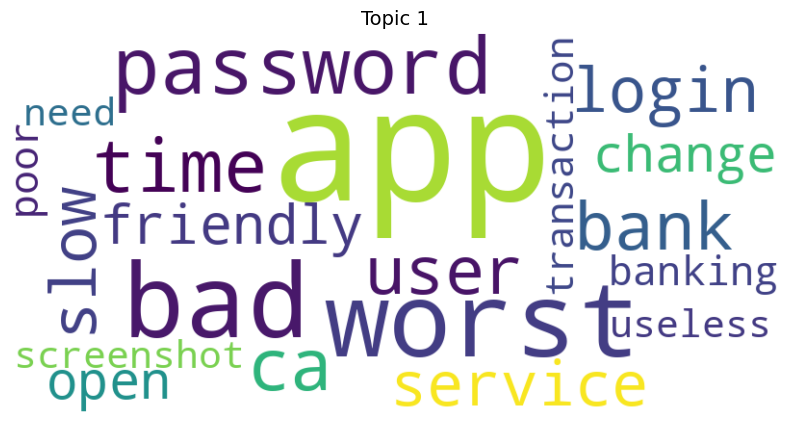

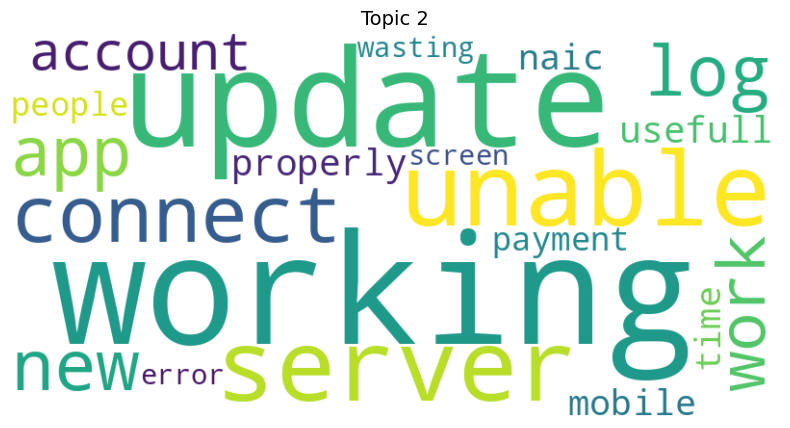

In [ ]:
# Generate word clouds for both topics
for topic, df in keywords_ranking.items():
    generate_wordcloud(df.head(20), topic)

In [ ]:
#Assign the most probable topic to each review
negative_reviews['topic'] = lda.transform(tfidf_dtm).argmax(axis=1)

<ipython-input-26-1c6ee9867e2a>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  negative_reviews['topic'] = lda.transform(tfidf_dtm).argmax(axis=1)


In [ ]:
# Map topic numbers to labels
topic_labels = {0: 'UI', 1: 'UX'}
negative_reviews['classification'] = negative_reviews['topic'].map(topic_labels)

<ipython-input-27-6f27e2f65528>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  negative_reviews['classification'] = negative_reviews['topic'].map(topic_labels)


In [ ]:
negative_reviews

,content,at,appVersion,cleaned_content,sentiment_score,sentiment,topic,classification
1,"Shows me a message after the latest update. ""T...",2025-01-25T06:12:57,V 1.36.1.2,shows message latest update device app signatu...,0.0000,negative,1,UX
2,Not opening without finger print. My phone is ...,2025-01-25T03:05:31,V 1.36.1.2,opening without finger print phone available f...,0.0000,negative,1,UX
4,Every time Unable connect server what's this ð...,2025-01-23T12:39:13,V 1.34.1.2,every time unable connect server,0.0000,negative,1,UX
6,Always app is not working.It says server timeout,2025-01-21T05:26:13,V 1.34.1.2,always app says server timeout,0.0000,negative,0,UI
8,"Sometimes when using it, its functionality doe...",2025-01-13T08:15:39,V 1.34.1.2,sometimes using functionality seem work unable...,0.0000,negative,1,UX
...,...,...,...,...,...,...,...,...
911,"After we transfer to money to other account,ca...",2022-01-25T08:25:56,V 1.24.1.2,transfer money account ca download responsible,-0.2411,negative,0,UI
912,I am using my mobile phone to connect. But eve...,2022-01-24T03:14:41,V 1.24.1.2,using mobile phone connect everytime trying lo...,0.0000,negative,1,UX
916,Register step 3 problem,2022-01-17T09:37:47,V 1.24.1.2,register step 3 problem,-0.4019,negative,0,UI
917,Too much authentication,2022-01-14T23:48:56,V 1.24.1.2,much authentication,0.0000,negative,1,UX


In [ ]:
negative_reviews['classification'].value_counts()

,count
classification,
UI,313
UX,137


In [ ]:
feature_categories = {
    # UI Features
    "Login Process": ["login", "password"],
    "App Performance": ["slow", "worst", "time"],
    "Navigation": ["open", "user","friendly"],
    "Visual Design & Usability": ["poor", "bad", "useless"],
    "Design Updates": ["change", "need"],

    # UX Features
    "Transaction Flow": ["account", "work", "properly", "payment"],
    "Error Handling": ["error", "screen", "unable", "connect", "server"],
    "Update Mechanism": ["update", "new"],
    "User Experience": ["wasting", "time", "mobile", "useful"]
}

In [ ]:
def categorize_review(text):
    """Map review text to feature categories"""
    text = str(text).lower()
    matched_features = []

    for feature, keywords in feature_categories.items():
        if any(keyword in text for keyword in keywords):
            matched_features.append(feature)

    return ', '.join(matched_features) if matched_features else "Other Issues"

In [ ]:
# Add feature category column
negative_reviews['feature_category'] = negative_reviews['cleaned_content'].apply(categorize_review)


<ipython-input-32-35bc8b2b86d8>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  negative_reviews['feature_category'] = negative_reviews['cleaned_content'].apply(categorize_review)


In [ ]:
negative_reviews

,content,at,appVersion,cleaned_content,sentiment_score,sentiment,topic,classification,feature_category
1,"Shows me a message after the latest update. ""T...",2025-01-25T06:12:57,V 1.36.1.2,shows message latest update device app signatu...,0.0000,negative,1,UX,Update Mechanism
2,Not opening without finger print. My phone is ...,2025-01-25T03:05:31,V 1.36.1.2,opening without finger print phone available f...,0.0000,negative,1,UX,Navigation
4,Every time Unable connect server what's this ð...,2025-01-23T12:39:13,V 1.34.1.2,every time unable connect server,0.0000,negative,1,UX,"App Performance, Error Handling, User Experience"
6,Always app is not working.It says server timeout,2025-01-21T05:26:13,V 1.34.1.2,always app says server timeout,0.0000,negative,0,UI,"App Performance, Error Handling, User Experience"
8,"Sometimes when using it, its functionality doe...",2025-01-13T08:15:39,V 1.34.1.2,sometimes using functionality seem work unable...,0.0000,negative,1,UX,"App Performance, Transaction Flow, Error Handl..."
...,...,...,...,...,...,...,...,...,...
911,"After we transfer to money to other account,ca...",2022-01-25T08:25:56,V 1.24.1.2,transfer money account ca download responsible,-0.2411,negative,0,UI,Transaction Flow
912,I am using my mobile phone to connect. But eve...,2022-01-24T03:14:41,V 1.24.1.2,using mobile phone connect everytime trying lo...,0.0000,negative,1,UX,"Login Process, App Performance, Error Handling..."
916,Register step 3 problem,2022-01-17T09:37:47,V 1.24.1.2,register step 3 problem,-0.4019,negative,0,UI,Other Issues
917,Too much authentication,2022-01-14T23:48:56,V 1.24.1.2,much authentication,0.0000,negative,1,UX,Other Issues


<ipython-input-31-29a3ea56f7bc>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ui_category_counts.index, y=ui_category_counts.values, palette="Blues")


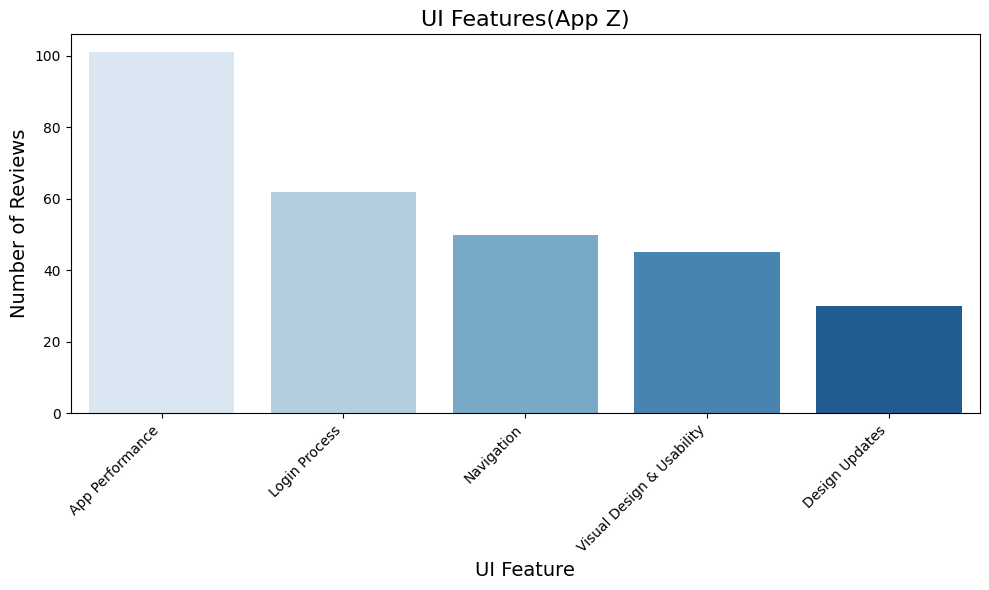

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define UI features (from your feature categories)
ui_features = ["Login Process", "App Performance", "Navigation", "Design Updates", "Visual Design & Usability"]

# Ensure multiple feature categories are counted separately
negative_reviews_exploded = negative_reviews.assign(feature_category=negative_reviews['feature_category'].str.split(', ')).explode('feature_category')

# Filter only UI-related features
ui_reviews = negative_reviews_exploded[negative_reviews_exploded['feature_category'].isin(ui_features)]

# Count occurrences of each UI feature
ui_category_counts = ui_reviews['feature_category'].value_counts()

# Plot the bar chart for UI Features
plt.figure(figsize=(10, 6))
sns.barplot(x=ui_category_counts.index, y=ui_category_counts.values, palette="Blues")

plt.title('UI Features(App Z)', fontsize=16)
plt.xlabel('UI Feature', fontsize=14)
plt.ylabel('Number of Reviews', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

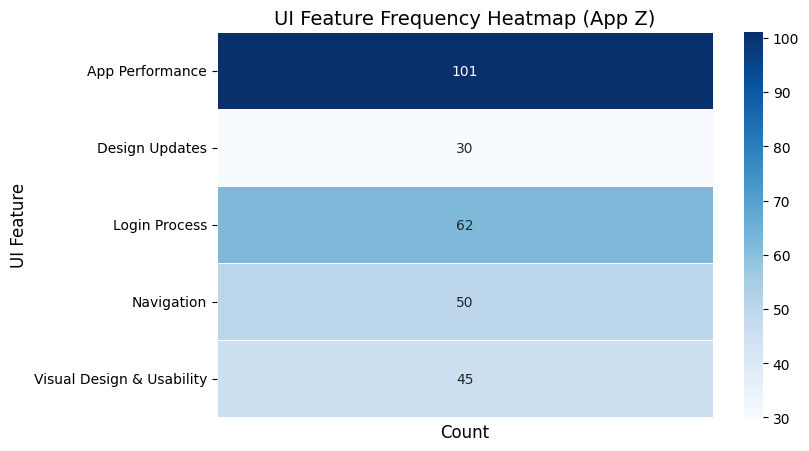

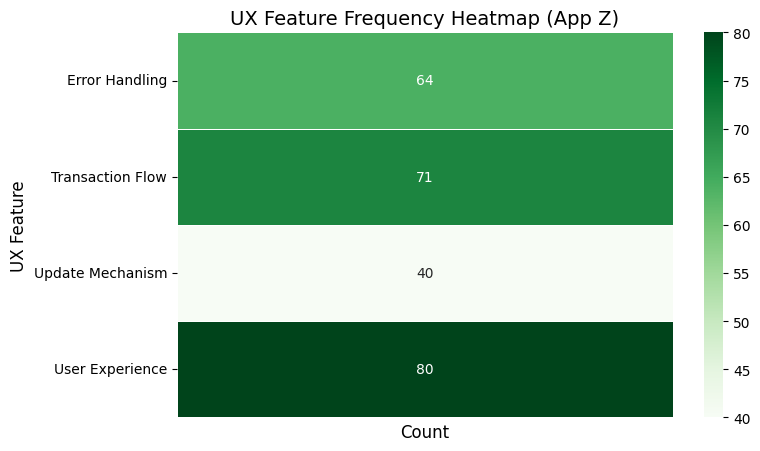

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Define UI and UX feature categories
ui_features = ["Login Process", "App Performance", "Navigation", "Design Updates", "Visual Design & Usability"]
ux_features = ["Transaction Flow", "Error Handling", "Update Mechanism","User Experience"]

# Ensure multiple feature categories are counted separately
negative_reviews_exploded = negative_reviews.assign(
    feature_category=negative_reviews['feature_category'].str.split(', ')
).explode('feature_category')

# Separate UI and UX feature counts
ui_feature_counts = negative_reviews_exploded[negative_reviews_exploded['feature_category'].isin(ui_features)]['feature_category'].value_counts()
ux_feature_counts = negative_reviews_exploded[negative_reviews_exploded['feature_category'].isin(ux_features)]['feature_category'].value_counts()

# Convert to DataFrame for heatmap format
ui_feature_df = pd.DataFrame(ui_feature_counts).reset_index()
ui_feature_df.columns = ['Feature', 'Count']

ux_feature_df = pd.DataFrame(ux_feature_counts).reset_index()
ux_feature_df.columns = ['Feature', 'Count']

# Reshape data for heatmaps
ui_heatmap_data = pd.pivot_table(ui_feature_df, values='Count', index='Feature', aggfunc='sum')
ux_heatmap_data = pd.pivot_table(ux_feature_df, values='Count', index='Feature', aggfunc='sum')

# Plot UI heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(ui_heatmap_data, annot=True, cmap="Blues", linewidths=0.5, fmt='g')
plt.title('UI Feature Frequency Heatmap (App Z)', fontsize=14)
plt.xlabel('Count', fontsize=12)
plt.ylabel('UI Feature', fontsize=12)
plt.xticks([])
plt.yticks(rotation=0)
plt.show()

# Plot UX heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(ux_heatmap_data, annot=True, cmap="Greens", linewidths=0.5, fmt='g')
plt.title('UX Feature Frequency Heatmap (App Z)', fontsize=14)
plt.xlabel('Count', fontsize=12)
plt.ylabel('UX Feature', fontsize=12)
plt.xticks([])
plt.yticks(rotation=0)
plt.show()

<ipython-input-35-27abb49ca282>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ux_category_counts.index, y=ux_category_counts.values, palette="Blues")


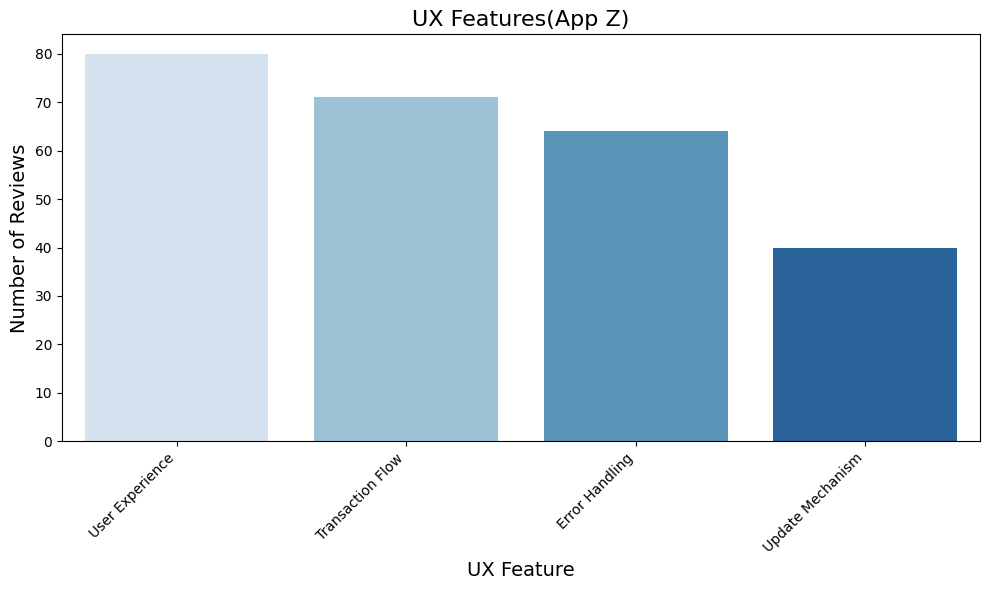

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define UI features (from your feature categories)
ux_features = ["Transaction Flow", "Error Handling", "Update Mechanism", "User Experience"]

# Ensure multiple feature categories are counted separately
negative_reviews_exploded = negative_reviews.assign(feature_category=negative_reviews['feature_category'].str.split(', ')).explode('feature_category')

# Filter only UI-related features
ux_reviews = negative_reviews_exploded[negative_reviews_exploded['feature_category'].isin(ux_features)]

# Count occurrences of each UI feature
ux_category_counts = ux_reviews['feature_category'].value_counts()

# Plot the bar chart for UI Features
plt.figure(figsize=(10, 6))
sns.barplot(x=ux_category_counts.index, y=ux_category_counts.values, palette="Blues")

plt.title('UX Features(App Z)', fontsize=16)
plt.xlabel('UX Feature', fontsize=14)
plt.ylabel('Number of Reviews', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()